## Data preparation

In [1]:
import matplotlib.pyplot as plt
from torch.functional import F
import yfinance as yf
from torch import nn
import numpy as np
import torch

Data for train, val, test shouldn't be shuffled, because this will lead to **temporal data leakage**. Model will see the future values of assets.

In [2]:
data = yf.download("BTC-USD", start="2016-06-01", end="2026-06-01")
data.shape

[*********************100%***********************]  1 of 1 completed


(3652, 5)

In [3]:
data.tail()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2026-05-27,74344.703125,76014.296875,74136.500000,75825.304688,33802172927
2026-05-28,73536.554688,74460.125000,72493.414062,74339.570312,40148145327
2026-05-29,73372.523438,74218.562500,72435.625000,73537.031250,34457929250
2026-05-30,73754.835938,74020.757812,73125.234375,73370.851562,19563589191
2026-05-31,73579.687500,74153.500000,73315.015625,73753.750000,17445435650


In [4]:
data.columns

MultiIndex([( 'Close', 'BTC-USD'),
            (  'High', 'BTC-USD'),
            (   'Low', 'BTC-USD'),
            (  'Open', 'BTC-USD'),
            ('Volume', 'BTC-USD')],
           names=['Price', 'Ticker'])

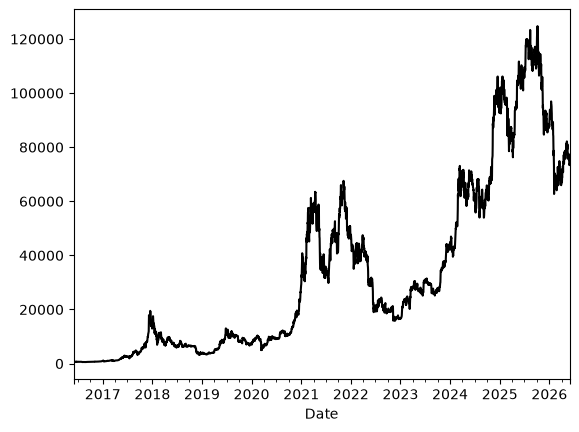

In [5]:
data['Close']['BTC-USD'].plot(cmap='gray');

In [6]:
values = data['Close']['BTC-USD'].values
len(values)

3652

In [7]:
# sliding window
windows = []
window_len = 80 # experiment with that later
images = []
for i in range(len(values) - window_len + 1):
    orig_window = values[i:i+window_len]
    windows.append(orig_window)

    # slice normalization
    # min-max scaling
    window = np.array(orig_window)
    max_value, min_value = window.max(), window.min()
    if min_value == max_value: # handle no change in values
        window = np.zeros_like(window)
    else:
        window = (window - min_value) / (max_value - min_value)

    matrix = np.zeros((window_len, window_len), dtype=np.float32)
    # where to place our value in a column
    for col_idx in range(window_len):
        # our values are from 0 to 1, so if value is 0.34 then
        # it signalises that it should be 34% from the bottom
        # so then it should be 66% from the top
        value = window[col_idx]
        value_row_idx = round((1 - window[col_idx]) * (window_len - 1))
        matrix[value_row_idx][col_idx] = 1 # drawing line on matrix
    images.append(matrix)

print(f'{len(windows)} {window_len}-day windows generated, \nso that {len(images)} training data graphs has been created')

3573 80-day windows generated, 
so that 3573 training data graphs has been created


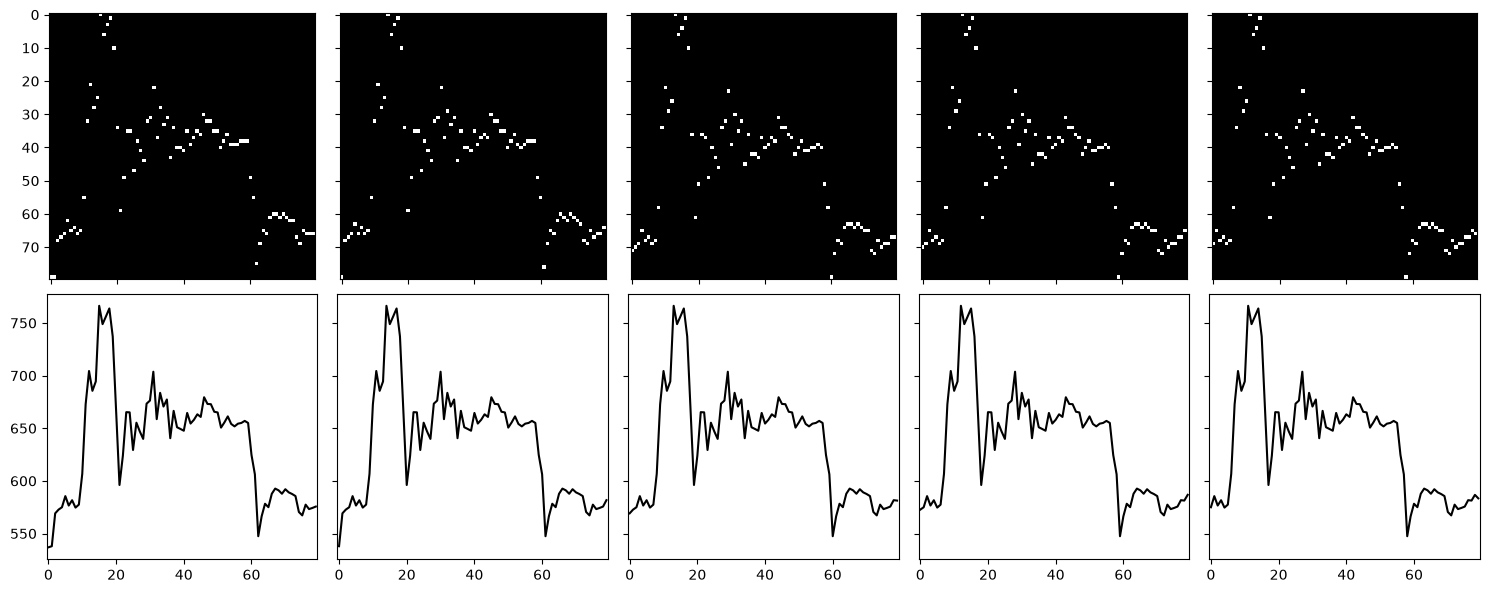

In [8]:
def compare_series_charts(steps=5):
    _, ax = plt.subplots(nrows=2,
                         ncols=steps,
                         figsize=(steps * 3, 6),
                         sharey='row',
                         sharex='col')
    for i in range(steps):
        ax[0][i].imshow(images[i], cmap='gray')
        ax[1][i].plot(windows[i], color='black')
    plt.tight_layout()
    plt.show()
compare_series_charts()

### X, Y division
Taking images and erasing the end of it - our models will have to predict that, so targets will be complete images representing time-series.

Copies:
* .copy() on np.ndarray - deep copy, totally separated
* .copy() on list - shallow copy, nested lists are mutable
* a = b - reference to the same object in memory

In [9]:
limit = 60 # 75% of full window
X = np.array(images).copy()
Y = np.array(images).copy()
X[:, :, limit:] = 0

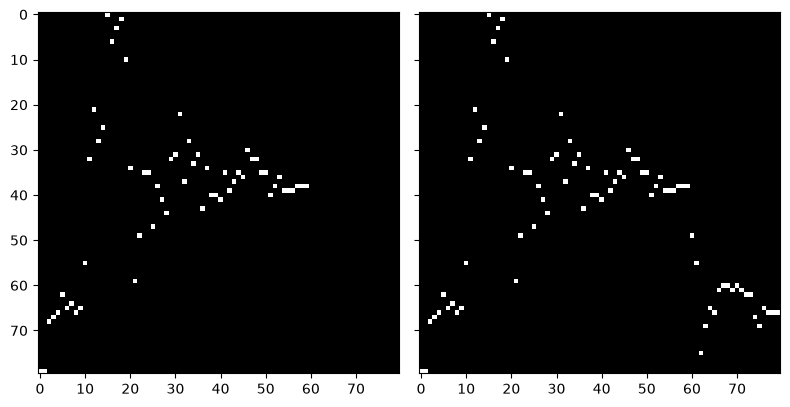

In [10]:
def show_x_and_target_difference():
    _, ax = plt.subplots(nrows=1,
                         ncols=2,
                         figsize=(8, 6),
                         sharey='row')
    ax[0].imshow(X[0], cmap='gray')
    ax[1].imshow(Y[0], cmap='gray')
    plt.tight_layout()
    plt.show()
show_x_and_target_difference()

### Splitting into train, val, test sets

I have chosen 80% for train, 10% val and 10% for test set.

In [11]:
print(X.shape)
print(Y.shape)

(3573, 80, 80)
(3573, 80, 80)


In [12]:
split_val = int(len(X) * 0.8)
split_test = int(len(X) * 0.9)

X_train, Y_train = X[:split_val], Y[:split_val]
X_val, Y_val = X[split_val:split_test], Y[split_val:split_test]
X_test, Y_test = X[split_test:], Y[split_test:]

splits = ['Train', 'Val', 'Test']
x_sets = [X_train, X_val, X_test]
y_sets = [Y_train, Y_val, Y_test]

for name, x_s, y_s in zip(splits, x_sets, y_sets):
    print(f'{name:5} -> X: {str(x_s.shape):18} Y: {str(y_s.shape)}')

Train -> X: (2858, 80, 80)     Y: (2858, 80, 80)
Val   -> X: (357, 80, 80)      Y: (357, 80, 80)
Test  -> X: (358, 80, 80)      Y: (358, 80, 80)


## Visual Encoder-Decoder Implementation

### What to improve later
* number of layers
* add batch normalization
* experiment with kernel sizes, stride, padding, dilation

### Quick recap
* kernel - filter that is being learned like 3x3, 5x5 matrix which goes through each image
* padding - addition of 0s to the borders to prevent image from shrinking
* stride - the step that each kernel takes
* dilation - how much we want kernel to expand - gain wider receptive field, but could lead to information being lost

### Models

Convolutional Autoencoder should systematically decrease spatial dimensions.

In [13]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=2, padding=2)
        self.conv2 = nn.Conv2d(64, 32, 3, 1, 1)
        self.conv3 = nn.Conv2d(32, 16, 3, 1, 1)
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(16 * 80 * 80, 128)

    def forward(self, x):
        print('input:', x.shape) # NCHW
        x = self.relu(self.conv1(x))
        print('conv1:', x.shape)
        x = self.relu(self.conv2(x))
        print('conv2:', x.shape)
        x = self.relu(self.conv3(x))
        print('conv3:', x.shape)
        x = self.flatten(x)
        print('flatten:', x.shape)
        x = self.linear(x)
        print('linear:', x.shape)
        return x

class Decoder(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.linear = nn.Linear(in_features, 102400)
        self.conv1 = nn.ConvTranspose2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.ConvTranspose2d(32, 64, 3, 1, 1)
        self.conv3 = nn.ConvTranspose2d(64, 1, 3, 1, 1)
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        print('input:', x.shape) # latent space
        x = self.linear(x)
        print('linear:', x.shape)
        x = x.reshape(x.shape[0], 16, 80, 80)
        print('reshaped:', x.shape)
        x = self.relu(self.conv1(x))
        print('conv1:', x.shape)
        x = self.relu(self.conv2(x))
        print('conv2:', x.shape)
        x = self.relu(self.conv3(x))
        print('conv3:', x.shape)
        x = self.sigmoid(x)
        return x
    

class VisualAE0(nn.Module):
    def __init__(self):
        ...

In [14]:
class VisualAE(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        
    def forward(self, x):
        latent = self.encoder(x)
        output = self.decoder(latent)
        return output

In [15]:
class EncoderPlainConv(nn.Module):
    def __init__(self, latent_dim=512):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=2, padding=1) # 80x80 -> 40x40
        self.conv2 = nn.Conv2d(64, 32, 3, 2, 1) # 40x40 -> 20x20
        self.conv3 = nn.Conv2d(32, 16, 3, 2, 1) # 20x20 -> 10x10
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten() # 16x10x10 -> 1600
        self.linear = nn.Linear(1600, latent_dim)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        # print(x.shape)
        x = self.relu(self.conv2(x))
        # print(x.shape)
        x = self.relu(self.conv3(x))
        # print(x.shape)
        x = self.flatten(x)
        # print(x.shape)
        x = self.linear(x)
        # print(x.shape)
        return x

class DecoderPlainConv(nn.Module):
    def __init__(self, latent_dim=512):
        super().__init__()
        self.linear = nn.Linear(latent_dim, 1600)
        self.conv1 = nn.ConvTranspose2d(16, 32, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.conv2 = nn.ConvTranspose2d(32, 64, 3, 2, 1, 1)
        self.conv3 = nn.ConvTranspose2d(64, 1, 3, 2, 1, 1)
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.linear(x)
        # print(x.shape)
        x = x.reshape(x.shape[0], 16, 10, 10)
        # print(x.shape)
        x = self.relu(self.conv1(x))
        # print(x.shape)
        x = self.relu(self.conv2(x))
        # print(x.shape)
        x = self.sigmoid(self.conv3(x))
        # print(x.shape)
        return x

In [16]:
class MaxPoolingEncoder(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 80x80 -> 40x40
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 40x40 -> 20x20
            
            nn.Flatten(),
            nn.Linear(64 * 20 * 20, latent_dim)
        )
    def forward(self, x): return self.net(x)

class UpsampleDecoder(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.linear = nn.Linear(latent_dim, 64 * 20 * 20)
        self.net = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True), # 20x20 -> 40x40
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True), # 40x40 -> 80x80
            nn.Conv2d(32, 1, kernel_size=3, padding=1),
            nn.Sigmoid()
        )
    def forward(self, x):
        x = self.linear(x).view(x.size(0), 64, 20, 20)
        return self.net(x)

In [17]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels)
        )
        self.relu = nn.ReLU()
        
    def forward(self, x):
        # Skip connection: Add the input directly back to the processed features
        return self.relu(x + self.conv(x))

class ResNetEncoder(nn.Module):
    def __init__(self, latent_dim=512):
        super().__init__()
        self.init_conv = nn.Conv2d(1, 64, 5, stride=2, padding=2) # 80x80 -> 40x40
        self.res_block = ResidualBlock(64)
        self.final_conv = nn.Conv2d(64, 128, 5, stride=2, padding=2) # 40x40 -> 20x20
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(128 * 20 * 20, latent_dim)
        
    def forward(self, x):
        x = torch.relu(self.init_conv(x))
        x = self.res_block(x)
        x = torch.relu(self.final_conv(x))
        return self.fc(self.flatten(x))
        
# (You would write a corresponding ResNetDecoder here to match shapes)

### Testing Encoder and Decoder

tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [1., 1., 0.,  ..., 0., 0., 0.]]]])


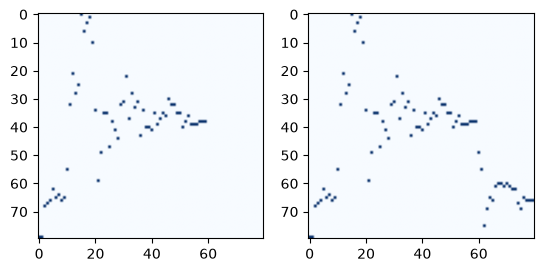

In [18]:
t = torch.tensor(X[0]).unsqueeze(0).unsqueeze(0)
print(t)
_, ax = plt.subplots(1, 2)
ax[0].imshow(X[0], cmap='Blues')
ax[1].imshow(Y[0], cmap='Blues')
plt.show()

In [19]:
# encoder = Encoder()
# decoder = Decoder(in_features=128)

# latent = encoder(t)
# output = decoder(latent)

In [20]:
# img_array = output.squeeze().detach().cpu().numpy()
# fig, ax = plt.subplots(figsize=(6, 6))
# im = ax.imshow(img_array, cmap='gray')
# cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
# cbar.set_label('Probability of value at certain time', rotation=270, labelpad=15)

# plt.show()

## Loss

The loss is presented as the sum of column-wise distances $d$ between our true and predicted images:

$$L(y, \hat{y}) = \sum_{i=1}^{w} d(y_i, \hat{y}_i)$$

Where $y$ represents the true ground-truth image and $\hat{y}$ represents the predicted image. The variable $w$ is the image width, and we are summing the distance $d$ of true columns $y_i$ and predicted columns $\hat{y}_i$.

In this case, our distance measure $d$ is the **Jensen-Shannon Divergence**, which is a symmetric and more stable version of the **Kullback-Leibler Divergence**.

---

Instead of using traditional pointwise metrics like Mean Squared Error (MSE), the model frames time-series forecasting as a column-wise probability distribution alignment problem. Each column in the image is treated as a discrete probability distribution where $x$ represents a specific pixel location (price row).

#### 1. Kullback-Leibler Divergence Equation

$$\mathcal{D}_{KL}(P \parallel Q) = \sum P(x) \log \left( \frac{P(x)}{Q(x)} \right)$$

* **$\frac{P(x)}{Q(x)}$ (The Ratio):** This compares the true probability $P(x)$ to the predicted probability $Q(x)$ at pixel $x$. If the network draws the line exactly where it belongs, the ratio becomes $1$, and $\log(1) = 0$, resulting in zero penalty.
* **$P(x) \cdot \log(\dots)$ (The Weighting):** The true chart line acts as a filter. If a pixel is supposed to be empty background ($P(x) = 0$), the entire term becomes $0$. This means the model is never penalized for background pixels and is forced to focus strictly on where the actual line should be drawn.

#### 2. Jensen-Shannon Divergence Equation

$$\mathcal{D}_{JS}(P \parallel Q) = \frac{1}{2} \left( \sum P(x) \log \left( \frac{P(x)}{M(x)} \right) + \sum Q(x) \log \left( \frac{Q(x)}{M(x)} \right) \right)$$

* **$M(x) = \frac{1}{2}(P(x) + Q(x))$ (The Midpoint):** Direct KL divergence breaks mathematically if the network outputs a zero where a line should be (causing division by zero or infinite values). To fix this, both the true distribution $P$ and the predicted distribution $Q$ are compared to their average midpoint, $M(x)$.
* **The Two Sums:** The first sum calculates how far the true chart line deviates from the midpoint, and the second calculates how far the predicted chart line deviates from the midpoint.
* **The $\frac{1}{2}$ Multiplier:** This averages those two directional differences. It smooths out gradients during training and strictly maps the final loss score into a clean error range between $0.0$ (perfect match) and $1.0$ (complete mismatch).

> This is calculated per two independent columns, but in our PyTorch implementation we vectorize and do everything at once across whole batch

In [21]:
y_pred = torch.randint(0, 10, (1, 5, 5))
print(y_pred)
s = y_pred.sum(dim=1, keepdim=True)
print(s)
print(y_pred / s)

tensor([[[8, 4, 4, 2, 5],
         [4, 5, 8, 4, 6],
         [9, 3, 8, 6, 1],
         [3, 0, 8, 5, 1],
         [8, 5, 4, 5, 1]]])
tensor([[[32, 17, 32, 22, 14]]])
tensor([[[0.2500, 0.2353, 0.1250, 0.0909, 0.3571],
         [0.1250, 0.2941, 0.2500, 0.1818, 0.4286],
         [0.2812, 0.1765, 0.2500, 0.2727, 0.0714],
         [0.0938, 0.0000, 0.2500, 0.2273, 0.0714],
         [0.2500, 0.2941, 0.1250, 0.2273, 0.0714]]])


In [22]:
torch.tensor([0, 2]).log()

tensor([  -inf, 0.6931])

In [23]:
def jsd_loss(y_pred, y_true):
    '''Sum of column-wise distances between the two images'''
    # Remove dim: [N, 1, H, W] -> [N, H, W]
    y_pred = y_pred.squeeze(1) # channel dim
    y_true = y_true.squeeze(1)
    epsilon = 1e-8 # prevents from division by 0

    # Computing vertical sums
    col_sums_pred = y_pred.sum(dim=1, keepdim=True)
    col_sums_true = y_true.sum(dim=1, keepdim=True)

    # Using these sums to transform cols into discrete probability distributions P and Q
    Q = y_pred / (col_sums_pred + epsilon)
    P = y_true / (col_sums_true + epsilon)
    # Now every column in image is a distribution

    # Get mean distribution
    M = 0.5 * (P + Q)

    # Computing Kullback-Leibler Divergence
    # (M + epsilon) to prevent having log0 which is -inf
    kl_div_p = F.kl_div((M + epsilon).log(), P, reduction='none')
    kl_div_q = F.kl_div((M + epsilon).log(), Q, reduction='none')

    # JSD
    # Sum divergences
    # Get error for each column
    # Get mean for each batch across columns
    # Get mean across batches
    jsd = 0.5 * (kl_div_p + kl_div_q).sum(dim=1).mean(dim=1).mean()
    return jsd

## Evaluation metrics

All evaluations are computed strictly over the **unobserved forecast region** (25%)

### Visual

#### Intersection-over-Union (IoU)

Computed by column across 20-day forecast. It works here like this:
* for each column locate pixels where chart line is present
* wrap 1D bounding box around these pixels
* calculate how much predicted box overlaps with true box

$$\text{IoU}_{column} = \frac{\text{Length of Overlap (Intersection)}}{\text{Total Span Covered Together (Union)}}$$

In [24]:
t = torch.tensor([[0, 0, 0.2, 1, 0, 1, 1],
                  [0, 0.1, 0.2, 1, 0, 0, 0],
                  [0, 0, 0, 1, 0, 0, 0],
                  [0, 0.15, 0.25, 0, 0, 1, 0]])
print(t)
row_coords = torch.arange(t.shape[0]).view(1, t.shape[0], 1)
print(row_coords)
pred_mask = t > 0.01
print(pred_mask)
pred_coords_max = torch.where(pred_mask, row_coords, 0)
print(pred_coords_max)
print(pred_coords_max.max(dim=1))
print(pred_coords_max.max(dim=1))

tensor([[0.0000, 0.0000, 0.2000, 1.0000, 0.0000, 1.0000, 1.0000],
        [0.0000, 0.1000, 0.2000, 1.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.1500, 0.2500, 0.0000, 0.0000, 1.0000, 0.0000]])
tensor([[[0],
         [1],
         [2],
         [3]]])
tensor([[False, False,  True,  True, False,  True,  True],
        [False,  True,  True,  True, False, False, False],
        [False, False, False,  True, False, False, False],
        [False,  True,  True, False, False,  True, False]])
tensor([[[0, 0, 0, 0, 0, 0, 0],
         [0, 1, 1, 1, 0, 0, 0],
         [0, 0, 0, 2, 0, 0, 0],
         [0, 3, 3, 0, 0, 3, 0]]])
torch.return_types.max(
values=tensor([[0, 3, 3, 2, 0, 3, 0]]),
indices=tensor([[0, 3, 3, 2, 0, 3, 0]]))
torch.return_types.max(
values=tensor([[0, 3, 3, 2, 0, 3, 0]]),
indices=tensor([[0, 3, 3, 2, 0, 3, 0]]))


In [25]:
def iou(y_pred, y_true):
    '''Compute col-wise 1D IoU'''
    y_pred = y_pred.squeeze(1) # NCHW -> NHW
    y_true = y_true.squeeze(1)
    threshold = 0.1
    batch_size, height, width = y_pred.shape

    # Create height indices [0, 1, ..., height] and reshape to (1, height, 1) - column vector
    row_coords = torch.arange(height).view(1, height, 1)

    # Generate masks
    pred_mask = y_pred > threshold
    true_mask = y_true > threshold

    # Get max and min coords for future bbox calculation
    pred_coords_max = torch.where(pred_mask, row_coords, 0)
    true_coords_max = torch.where(true_mask, row_coords, 0)
    pred_coords_min = torch.where(pred_mask, row_coords, 999)
    true_coords_min = torch.where(true_mask, row_coords, 999)

    # Extract bbox edges, top and bottom (min, max)
    min_p = pred_coords_min.min(dim=1).values
    max_p = pred_coords_max.max(dim=1).values
    min_t = true_coords_min.min(dim=1).values
    max_t = true_coords_max.max(dim=1).values

    # Intersection
    inter_min = torch.max(min_p, min_t)
    inter_max = torch.min(max_p, max_t)
    # + 1 ensures that if min=3 and max=3, the length is calculated as 1 pixel wide
    intersection = torch.clamp(inter_max - inter_min + 1, min=0) # prevents from intersection lower than 0

    # Union
    union_min = torch.min(min_p, min_t)
    union_max = torch.max(max_p, max_t)
    union = union_max - union_min + 1

    # IoU for all cols
    col_iou = intersection / union

    # Mean across columns, then mean across the whole batch
    return col_iou.mean(dim=1).mean()

### Numeric

#### Mean Absolute Scaled Error (MASE)

Tells how much better model is than *Naive One-Step Forecast* (guesses that next price will be the same)

$$\text{MASE} = \frac{\text{Mean Absolute Error of Forecast}}{\text{Mean Absolute Error of the In-Sample Naive Baseline}}$$

$$\text{MAE}_{\text{forecast}}$$

Shows the mean absolute difference between prediction and true forecasts.

$$\text{MAE}_{\text{baseline}}$$
Tells us how much this asset moves on average day by day. It is computed as a mean absolute difference between consecutive asset values in the baseline sector, not forecast.

In [26]:
def mase(y_pred, y_true, window_len=60):
    y_pred_forecast = y_pred[:, window_len:]
    y_true_forecast = y_true[:, window_len:]
    
    mae_forecast = torch.mean(torch.abs(y_true_forecast - y_pred_forecast))

    y_true_history = y_true[:, :window_len]
    
    yesterday = y_true_history[:, :-1]
    today = y_true_history[:, 1:]
    
    mae_baseline = torch.mean(torch.abs(today - yesterday))

    epsilon = 1e-8
    mase_result = mae_forecast / (mae_baseline + epsilon)
    return mase_result

In [27]:
s = torch.randn((4, 7))
s

tensor([[-2.2554, -1.3828, -0.3574,  0.6131, -0.3603, -1.7626, -1.5588],
        [ 0.4551,  1.0668, -0.3732,  0.9578,  0.1100, -0.6162,  0.8274],
        [-1.2298,  0.7137,  1.5056, -0.8717,  0.0573,  0.5624,  1.3838],
        [-1.9615, -2.0544,  1.1323,  0.2873,  0.7527, -0.0604, -0.6112]])

In [28]:
print(t - s)
print(torch.abs(t - s))
print(torch.mean(torch.abs(t - s), dim=0))

tensor([[ 2.2554,  1.3828,  0.5574,  0.3869,  0.3603,  2.7626,  2.5588],
        [-0.4551, -0.9668,  0.5732,  0.0422, -0.1100,  0.6162, -0.8274],
        [ 1.2298, -0.7137, -1.5056,  1.8717, -0.0573, -0.5624, -1.3838],
        [ 1.9615,  2.2044, -0.8823, -0.2873, -0.7527,  1.0604,  0.6112]])
tensor([[2.2554, 1.3828, 0.5574, 0.3869, 0.3603, 2.7626, 2.5588],
        [0.4551, 0.9668, 0.5732, 0.0422, 0.1100, 0.6162, 0.8274],
        [1.2298, 0.7137, 1.5056, 1.8717, 0.0573, 0.5624, 1.3838],
        [1.9615, 2.2044, 0.8823, 0.2873, 0.7527, 1.0604, 0.6112]])
tensor([1.4755, 1.3169, 0.8796, 0.6470, 0.3201, 1.2504, 1.3453])


## Training

In [29]:
from torch.utils.data import TensorDataset, DataLoader

In [30]:
def configure_optimization(model, init_lr=1e-3, weight_decay=1e-4):
    optimizer = torch.optim.AdamW(
        model.parameters(), 
        lr=init_lr, 
        weight_decay=weight_decay
    )
    # Reduce learning rate 10 times (by 0.1) if JSD loss stalled for 5 epochs
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min', 
        factor=0.1, 
        patience=5,
    )
    return optimizer, scheduler

In [31]:
def extract_1d_prices(y_image_matrix):
    '''
    Converts 2D probability grid [B, H, W] to 1D price index tracking [B, W]
    Usually used when we have image (matrix) and want to transform into casual form (1D numeric series)
    '''
    return torch.argmax(y_image_matrix, dim=1).float()

In [32]:
def build_dataloaders(X_tensor, Y_tensor, batch_size=128):
    '''
    Constructs train, val, and test groups cleanly from raw historical blocks
    without arbitrary indices or leakage traps.
    '''
    split_val = int(len(X_tensor) * 0.8)
    split_test = int(len(X_tensor) * 0.9)

    # Clean sequential chunk splits
    train_ds = TensorDataset(X_tensor[:split_val], Y_tensor[:split_val])
    val_ds   = TensorDataset(X_tensor[split_val:split_test], Y_tensor[split_val:split_test])
    test_ds  = TensorDataset(X_tensor[split_test:], Y_tensor[split_test:])

    # Time-series datasets MUST avoid shuffling to keep timeline boundaries clean, avoiding data leakage
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=False)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

In [33]:
def train_visual_model(model, train_loader, val_loader, epochs=50, device='cuda'):
    model = model.to(device)
    optimizer, scheduler = configure_optimization(model, init_lr=1e-3)

    best_val_loss = float('inf')
    early_stop_counter = 0

    # Initialize history dictionary to hold metrics for plotting
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_mase': [],
    }

    for epoch in range(epochs):
        print(f'Epoch {epoch+1}/{epochs} started...')
        
        # --- Training Phase ---
        model.train()
        train_loss = 0.0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = jsd_loss(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * batch_x.size(0)
            
        avg_train_loss = train_loss / len(train_loader.dataset)

        # --- Validation Phase ---
        model.eval()
        val_loss = 0.0
        val_mase = 0.0
        val_smape = 0.0
        
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                
                loss = jsd_loss(outputs, batch_y)
                val_loss += loss.item() * batch_x.size(0)
                
                # Cross-Metric Evaluation (Convert 2D Images to 1D continuous vectors)
                pred_prices = extract_1d_prices(outputs.squeeze(1))
                true_prices = extract_1d_prices(batch_y.squeeze(1))
                
                val_mase += mase(pred_prices, true_prices).item() * batch_x.size(0)

        avg_val_loss = val_loss / len(val_loader.dataset)
        avg_val_mase = val_mase / len(val_loader.dataset)
        # avg_val_smape = val_smape / len(val_loader.dataset)

        # Step Scheduler using the Validation Loss scalar
        scheduler.step(avg_val_loss)

        # Append metrics to history lists
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_mase'].append(avg_val_mase)
        # history['val_smape'].append(avg_val_smape)

        print(f'Epoch [{epoch+1:02d}/{epochs}] '
              f'Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | ')

        # --- Tracking & Early Stopping (15 Epoch Bounds) ---
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), 'visual_ae_plain_conv.pt')
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            if early_stop_counter >= 15:
                print(f' Early stopping triggered at epoch {epoch+1}. Training terminated.')
                break

    # Return the collected history dictionary for downstream plotting
    return history

In [34]:
batch_size = 32
epochs = 50
device = 'cuda' if torch.cuda.is_available() else 'cpu'
X_tensor = torch.tensor(X, device=device).unsqueeze(1)
Y_tensor = torch.tensor(Y, device=device).unsqueeze(1)
train_loader, val_loader, test_loader = build_dataloaders(X_tensor, Y_tensor, batch_size=batch_size)

In [35]:
torch.cuda.is_available()

True

In [36]:
X_tensor.shape

torch.Size([3573, 1, 80, 80])

In [37]:
latent_dim = 128
encoder = EncoderPlainConv(latent_dim)
decoder = DecoderPlainConv(latent_dim)
model = VisualAE(encoder, decoder)

In [38]:
history = train_visual_model(model, train_loader, val_loader, epochs, device)

Epoch 1/50 started...
Epoch [01/50] Train Loss: 0.6595 | Val Loss: 0.6582 | 
Epoch 2/50 started...
Epoch [02/50] Train Loss: nan | Val Loss: nan | 
Epoch 3/50 started...
Epoch [03/50] Train Loss: nan | Val Loss: nan | 
Epoch 4/50 started...
Epoch [04/50] Train Loss: nan | Val Loss: nan | 
Epoch 5/50 started...
Epoch [05/50] Train Loss: nan | Val Loss: nan | 
Epoch 6/50 started...
Epoch [06/50] Train Loss: nan | Val Loss: nan | 
Epoch 7/50 started...
Epoch [07/50] Train Loss: nan | Val Loss: nan | 
Epoch 8/50 started...
Epoch [08/50] Train Loss: nan | Val Loss: nan | 
Epoch 9/50 started...
Epoch [09/50] Train Loss: nan | Val Loss: nan | 
Epoch 10/50 started...
Epoch [10/50] Train Loss: nan | Val Loss: nan | 
Epoch 11/50 started...
Epoch [11/50] Train Loss: nan | Val Loss: nan | 
Epoch 12/50 started...
Epoch [12/50] Train Loss: nan | Val Loss: nan | 
Epoch 13/50 started...
Epoch [13/50] Train Loss: nan | Val Loss: nan | 
Epoch 14/50 started...
Epoch [14/50] Train Loss: nan | Val Loss: na

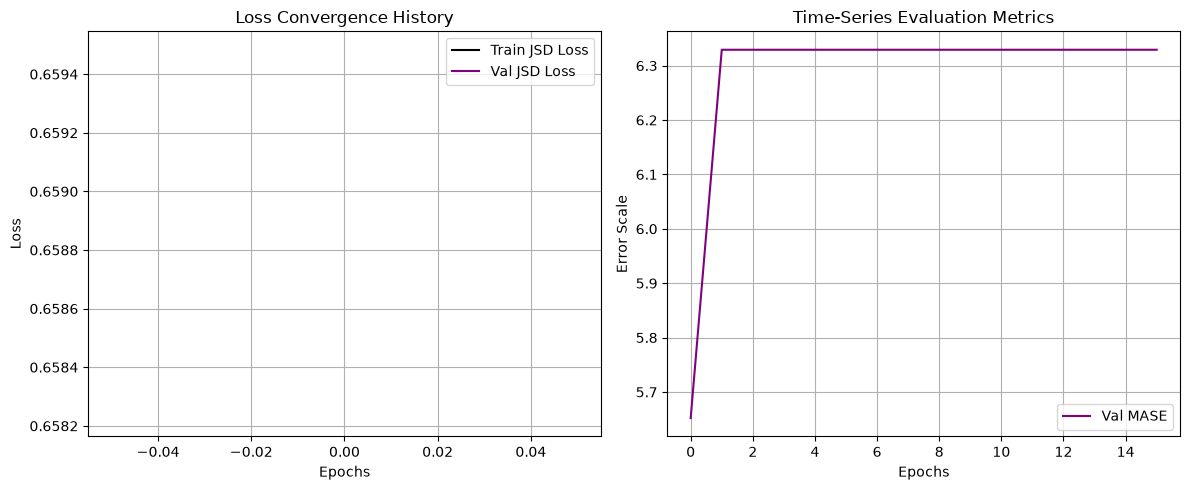

In [42]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train JSD Loss', color='black')
plt.plot(history['val_loss'], label='Val JSD Loss', color='purple')
plt.title('Loss Convergence History')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['val_mase'], label='Val MASE', color='purple')
plt.title('Time-Series Evaluation Metrics')
plt.xlabel('Epochs')
plt.ylabel('Error Scale')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()